<a href="https://colab.research.google.com/github/mavaxexcellence-commits/veggie-zombies-game-one/blob/main/IA_asset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install diffusers transformers accelerate torch torchvision

In [4]:
!pip install pillow

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
from diffusers import StableDiffusionPipeline

# Load a pre-trained Stable Diffusion model
# You can choose a different model if needed, e.g., "runwayml/stable-diffusion-v1-5"
model_id = "CompVis/stable-diffusion-v1-4"
pipe = StableDiffusionPipeline.from_pretrained(model_id)

# Move the pipeline to GPU if available
if torch.cuda.is_available():
    pipe.to("cuda")

print(f"Stable Diffusion model '{model_id}' loaded successfully.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion model 'CompVis/stable-diffusion-v1-4' loaded successfully.


In [26]:
import os
from PIL import Image

dataset_path = "https://drive.google.com/drive/folders/1kaE1lv3Obz9RG4UpW7ErEU1bxB5zSXtW"


images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".png") or file.endswith(".jpg"):
            img = Image.open(os.path.join(root, file))
            images.append(img)

print("Nombre d'images:", len(images))

Nombre d'images: 0


In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor()
])

processed_images = [transform(img) for img in images]

In [18]:
import torch

optimizer = torch.optim.Adam(pipe.unet.parameters(), lr=1e-5)

for epoch in range(5):
    for img in processed_images:
        img = img.unsqueeze(0).to("cuda")

        loss = pipe.unet(img).sample.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch terminé:", epoch)

Epoch terminé: 0
Epoch terminé: 1
Epoch terminé: 2
Epoch terminé: 3
Epoch terminé: 4


  0%|          | 0/50 [00:00<?, ?it/s]

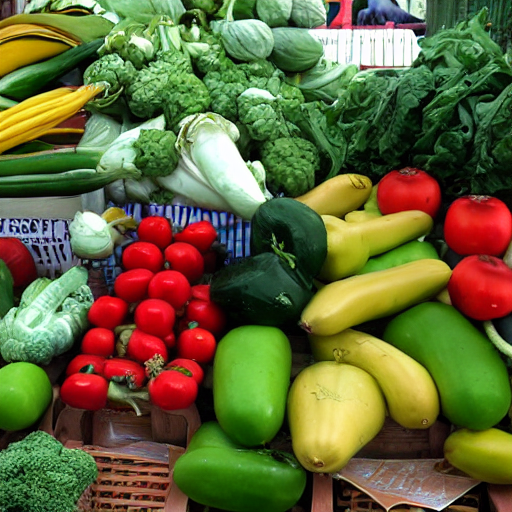

In [28]:
image = pipe("asset de personnage en légumes").images[0]

image.save("asset_en_personnage_légumes.png")
image